In [2]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import pickle

from diffvis.diffusion import initialize_diffusion_model, DiffSSI
from diffvis.data import Metadiff, permute_dimensions, reverse_transform

from dflat.render import hsi_to_rgb

In [3]:
config_path = "./models/metalens_arad256_models/mgs/config.yaml"
ckpt_path = "./models/metalens_arad256_models/mgs/model_snapshots/ckpt_last.ckpt"
model = initialize_diffusion_model(config_path, ckpt_path, True).to('cuda')

Target Module: diffvis.diffusion.ddpm.DDPM
Setting up Multiheaded attention with XFORMERS library: Spatial Atten.
Setting up Multiheaded attention with XFORMERS library: Spatial Atten.
Setting up Multiheaded attention with XFORMERS library: Spatial Atten.
Setting up Multiheaded attention with XFORMERS library: Spatial Atten.
Setting up Multiheaded attention with XFORMERS library: Spatial Atten.
Setting up Multiheaded attention with XFORMERS library: Spatial Atten.
Setting up Multiheaded attention with XFORMERS library: Spatial Atten.
Setting up Multiheaded attention with XFORMERS library: Spatial Atten.
Setting up Multiheaded attention with XFORMERS library: Spatial Atten.
Setting up Multiheaded attention with XFORMERS library: Spatial Atten.
Setting up Multiheaded attention with XFORMERS library: Spatial Atten.
Training DDPM without cross-attention conditioning.
Using identity as the concatenation transform.
Loading from checkpoint ./models/metalens_arad256_models/mgs/model_snapshots/

/home/deanhazineh/ssd4tb_mounted/DiffVis/diffvis/diffusion/load_utils.py:103: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  sd = torch.load(ckpt_path, map_location="cpu")["s

Restored with 0 missing and 0 unexpected keys


# Run Base DDPM Model Sampler on a Patch

['ARAD_valid_0.h5', 'ARAD_valid_1.h5', 'ARAD_valid_2.h5', 'ARAD_valid_3.h5', 'ARAD_valid_4.h5', 'ARAD_valid_5.h5', 'ARAD_valid_6.h5', 'ARAD_valid_7.h5', 'ARAD_valid_8.h5', 'ARAD_valid_9.h5', 'ARAD_valid_10.h5', 'ARAD_valid_11.h5', 'ARAD_valid_12.h5', 'ARAD_valid_13.h5', 'ARAD_valid_14.h5', 'ARAD_valid_15.h5', 'ARAD_valid_16.h5', 'ARAD_valid_17.h5', 'ARAD_valid_18.h5', 'ARAD_valid_19.h5', 'ARAD_valid_20.h5', 'ARAD_valid_21.h5', 'ARAD_valid_22.h5', 'ARAD_valid_23.h5', 'ARAD_valid_24.h5', 'ARAD_valid_25.h5', 'ARAD_valid_26.h5', 'ARAD_valid_27.h5', 'ARAD_valid_28.h5', 'ARAD_valid_29.h5', 'ARAD_valid_30.h5', 'ARAD_valid_31.h5', 'ARAD_valid_32.h5', 'ARAD_valid_33.h5', 'ARAD_valid_34.h5', 'ARAD_valid_35.h5', 'ARAD_valid_36.h5', 'ARAD_valid_37.h5', 'ARAD_valid_38.h5', 'ARAD_valid_39.h5', 'ARAD_valid_40.h5', 'ARAD_valid_41.h5', 'ARAD_valid_42.h5', 'ARAD_valid_43.h5', 'ARAD_valid_44.h5', 'ARAD_valid_45.h5', 'ARAD_valid_46.h5', 'ARAD_valid_47.h5', 'ARAD_valid_48.h5', 'ARAD_valid_49.h5']


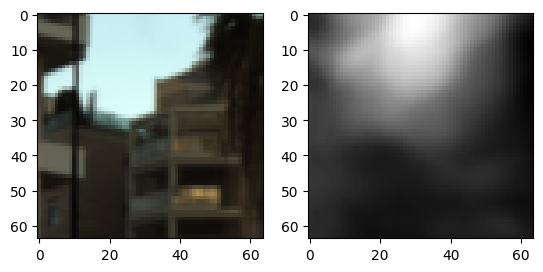

In [5]:
wl = np.linspace(400e-9, 700e-9, 31)
root_dir = "/home/deanhazineh/ssd4tb_mounted/DiffVis/scripts/datasets/metalens_prerendered/prerendered_L4s_256/"
dataset = Metadiff(
    root_dir,
    patchsize=64,
    patch_normalize=True,
    scale_shift_preprocess=True,
    data_fields=["hsi", "mgs"],
    eager_mode=False,
    use_aug=False,
    include=["ARAD_valid"],
)

sample = dataset[0]
hsi = sample["hsi"]
mgs = sample["mgs"]

hsi_rgb = hsi_to_rgb((hsi+1)/2, wl, tensor_ordering=True)
mgs_gs = (mgs+1)/2
fig, ax = plt.subplots(1,2)
ax[0].imshow(permute_dimensions(hsi_rgb))
ax[1].imshow(permute_dimensions(mgs_gs), cmap='gray')

In [6]:
samples, _ = model.sample(
    [64,64],
    batch_size=1,
    variance_n=1,
    return_intermediate=False,
    x_start=None,
    xcond=None,
    ccond=mgs[None],
)

sampling loop time step: 100%|██████████| 1000/1000 [00:11<00:00, 85.14it/s]


(64, 64, 31) (64, 64, 31)


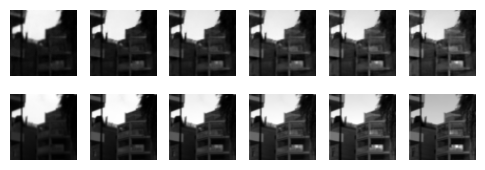

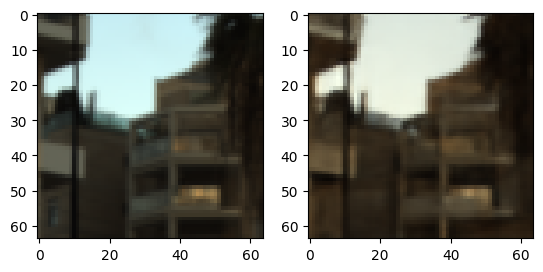

In [7]:
est = reverse_transform(samples)[0,0,0]
gt_hsi = reverse_transform(hsi)

widx = np.linspace(0, 30, 6).astype(int)
fig, ax = plt.subplots(2,6, figsize=(6*1,2*1))
for it, id in enumerate(widx):
    ax[0,it].imshow(est[:,:,id], cmap='gray')
    ax[1,it].imshow(gt_hsi[:,:,id], cmap='gray')

for axi in ax.flatten():
    axi.axis('off')

print(est.shape, gt_hsi.shape)
fig, ax = plt.subplots(1,2)
ax[0].imshow(hsi_to_rgb(gt_hsi, wl))
ax[1].imshow(hsi_to_rgb(est, wl))

# Apply Guided DDIM Sampler to Reconstruct and Synchronize Patches

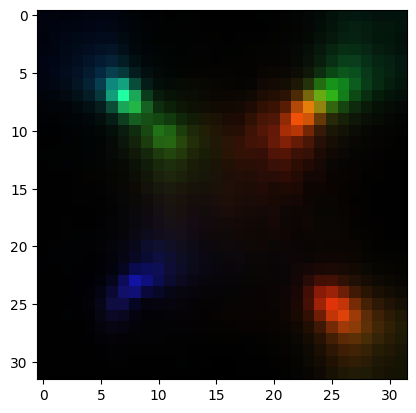

In [8]:
psf_path = "/home/deanhazineh/ssd4tb_mounted/DiffVis/scripts/metasurfaces/L4s_lens_psf_compact32.pickle"
with open(psf_path, "rb") as file:
    data = pickle.load(file)
    psf = data["psf_int"]
    psf = psf / np.max(psf)
    wl = data["wl"]
psf = torch.tensor(psf, device='cuda', dtype=torch.float32)
kernel = psf[None] / torch.max(psf)

psf_rgb = hsi_to_rgb(kernel, wl, tensor_ordering=True)
fig, ax = plt.subplots(1,1)
ax.imshow(permute_dimensions(psf_rgb[0]))

['ARAD_valid_0.h5', 'ARAD_valid_1.h5', 'ARAD_valid_2.h5', 'ARAD_valid_3.h5', 'ARAD_valid_4.h5', 'ARAD_valid_5.h5', 'ARAD_valid_6.h5', 'ARAD_valid_7.h5', 'ARAD_valid_8.h5', 'ARAD_valid_9.h5', 'ARAD_valid_10.h5', 'ARAD_valid_11.h5', 'ARAD_valid_12.h5', 'ARAD_valid_13.h5', 'ARAD_valid_14.h5', 'ARAD_valid_15.h5', 'ARAD_valid_16.h5', 'ARAD_valid_17.h5', 'ARAD_valid_18.h5', 'ARAD_valid_19.h5', 'ARAD_valid_20.h5', 'ARAD_valid_21.h5', 'ARAD_valid_22.h5', 'ARAD_valid_23.h5', 'ARAD_valid_24.h5', 'ARAD_valid_25.h5', 'ARAD_valid_26.h5', 'ARAD_valid_27.h5', 'ARAD_valid_28.h5', 'ARAD_valid_29.h5', 'ARAD_valid_30.h5', 'ARAD_valid_31.h5', 'ARAD_valid_32.h5', 'ARAD_valid_33.h5', 'ARAD_valid_34.h5', 'ARAD_valid_35.h5', 'ARAD_valid_36.h5', 'ARAD_valid_37.h5', 'ARAD_valid_38.h5', 'ARAD_valid_39.h5', 'ARAD_valid_40.h5', 'ARAD_valid_41.h5', 'ARAD_valid_42.h5', 'ARAD_valid_43.h5', 'ARAD_valid_44.h5', 'ARAD_valid_45.h5', 'ARAD_valid_46.h5', 'ARAD_valid_47.h5', 'ARAD_valid_48.h5', 'ARAD_valid_49.h5']
torch.Siz

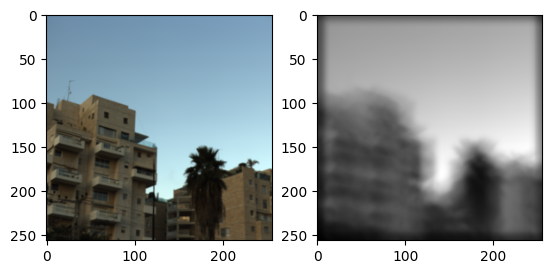

In [9]:
wl = np.linspace(400e-9, 700e-9, 31)
root_dir = "/home/deanhazineh/ssd4tb_mounted/DiffVis/scripts/datasets/metalens_prerendered/prerendered_L4s_256/"
dataset = Metadiff(
    root_dir,
    patchsize=None,
    patch_normalize=False,
    scale_shift_preprocess=False,
    data_fields=["hsi", "mgs"],
    eager_mode=False,
    use_aug=False,
    include=["ARAD_valid"],
)

sample = dataset[0]
hsi = sample["hsi"]
mgs = sample["mgs"]

print(hsi.shape, hsi.min(), hsi.max())
print(mgs.shape, mgs.min(), mgs.max())

hsi_rgb = hsi_to_rgb( hsi, wl, tensor_ordering=True)
fig, ax = plt.subplots(1,2)
ax[0].imshow(permute_dimensions(hsi_rgb))
ax[1].imshow(permute_dimensions(mgs), cmap='gray')

In [10]:
sampler = DiffSSI(model, n_steps=50, gloop=1, kernel=kernel, mode="gs", gscale=10)
im, x0, loss = sampler.sample(mgs, variance_n=1, use_guidance=True, return_intermediate=False)
ref_im, ref_x0, ref_loss = sampler.sample(mgs, variance_n=1, use_guidance=False, return_intermediate=False)

/home/deanhazineh/ssd4tb_mounted/DiffVis/diffvis/diffusion/sampler_guided_ddim.py:1709: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.kernel = torch.tensor(kernel, dtype=torch.float32, device="cuda")
  0%|          | 0/51 [00:00<?, ?it/s]/home/deanhazineh/anaconda3/envs/diffvis/lib/python3.11/site-packages/torch/_dynamo/eval_frame.py:632: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/home/deanhazineh/anaconda3/envs/diffvis/lib/python3.11/site-packages/torch/utils/checkpoint.py:87: Us

Text(0.5, 1.0, 'GT RGB Projection')

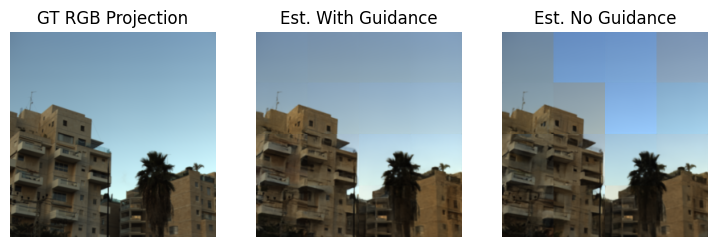

In [11]:
est = im[0,0] / im.max()
est_rgb_full = hsi_to_rgb( est, wl, tensor_ordering=True)
ref_est_rgb_full = hsi_to_rgb( np.mean(ref_im[-1],axis=0), wl, tensor_ordering=True)

fig, ax = plt.subplots(1,3, figsize=(3*3, 3))
ax[0].imshow(permute_dimensions(hsi_rgb))
ax[1].imshow(permute_dimensions(est_rgb_full))
ax[2].imshow(permute_dimensions(ref_est_rgb_full))

for axi in ax.flatten():
    axi.axis('off')

ax[2].set_title("Est. No Guidance")
ax[1].set_title("Est. With Guidance")
ax[0].set_title("GT RGB Projection")

# View other reconstructions

In [12]:
def norm_est(im, scale):
    est = im[0] / np.mean(im[0], axis=(-1,-2,-3), keepdims=True) / scale
    avg_est = np.mean(est, axis=0)
    avg_est_rgb = hsi_to_rgb(avg_est, wl, tensor_ordering=True)
    unc = np.sum(np.var(est, axis=0), axis=0)

    return est, avg_est, avg_est_rgb, unc

def display_result(hsi, im, ref_im, locs):
    hsi_rgb = permute_dimensions(hsi_to_rgb(hsi, wl, tensor_ordering=True))
    gt_hsi = hsi.cpu().numpy() / np.mean(hsi.cpu().numpy())
    scale = np.max(gt_hsi)
    gt_hsi /= scale
    est, avg_est, avg_est_rgb, unc = norm_est(im, scale)
    ref_est, ref_avg_est, ref_avg_est_rgb, ref_unc = norm_est(ref_im, scale)
    lam = wl*1e9

    fs_text = 14
    fig, ax = plt.subplots(2, 5, figsize=(5*3, 2*3))
    ax[0,0].imshow(hsi_rgb)
    ax[0,0].axis('off')
    ax[0,0].set_title("Scene RGB", fontsize=fs_text)

    ax[0,1].imshow(permute_dimensions(mgs), cmap='gray')
    ax[0,1].axis('off')
    ax[0,1].set_title("Measurement", fontsize=fs_text)

    ax[1,0].imshow(permute_dimensions(avg_est_rgb))
    ax[1,0].axis('off')
    ax[1,0].set_title("Estimated HSI (RGB)", fontsize=fs_text)

    ax[1,1].imshow(np.power(unc, 0.5), cmap='magma')
    ax[1,1].axis('off')
    ax[1,1].set_title("Estimated Uncertainty", fontsize=fs_text)

    ax[0,2].plot(loss, 'g-')
    ax[0,2].plot(ref_loss, 'm-')
    ax[0,2].set_xlabel("DDIM Step", fontsize=fs_text)
    ax[0,2].set_ylabel("Projection Error", fontsize=fs_text)
    ax[0,2].set_title("Estimate Consistency", fontsize=fs_text)
    [ax[0,it].axis('off') for it in np.arange(3,5)]

    markers = ['o', 's', '^', 'v']
    marker_symbols = ['⬤', '■', '▲', '▼']
    for it, (y,x) in enumerate(locs):
        ax[0,0].scatter(x,y, marker=markers[it], s=50, color='r')
        ax[1,0].scatter(x,y, marker=markers[it], s=50, color='r')

        ax[1,it+2].plot(lam, avg_est[:,y,x], 'g-', linewidth=4)
        ax[1,it+2].fill_between(lam, np.min(est[:,:,y,x], axis=0),  np.max(est[:,:,y,x], axis=0), color='g', alpha=0.25)
        ax[1,it+2].fill_between(lam, np.min(ref_est[:,:,y,x], axis=0),  np.max(ref_est[:,:,y,x], axis=0), color='m', alpha=0.1)
        ax[1,it+2].plot(lam, gt_hsi[:,y,x], 'ko')
        legend = ax[1,it+2].legend(title=f'{marker_symbols[it]}', fontsize=30, loc="upper left", frameon=False)
        legend.get_title().set_color('red')  


    ax[1,2].set_ylabel("Radiance", fontsize=fs_text)
    ax[1,3].set_xlabel("Wavelength (nm)", fontsize=fs_text)
    plt.tight_layout()

    return

/home/deanhazineh/ssd4tb_mounted/DiffVis/diffvis/diffusion/sampler_guided_ddim.py:1709: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.kernel = torch.tensor(kernel, dtype=torch.float32, device="cuda")
  0%|          | 0/51 [00:00<?, ?it/s]/home/deanhazineh/anaconda3/envs/diffvis/lib/python3.11/site-packages/torch/_dynamo/eval_frame.py:632: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/home/deanhazineh/anaconda3/envs/diffvis/lib/python3.11/site-packages/torch/utils/checkpoint.py:87: Us

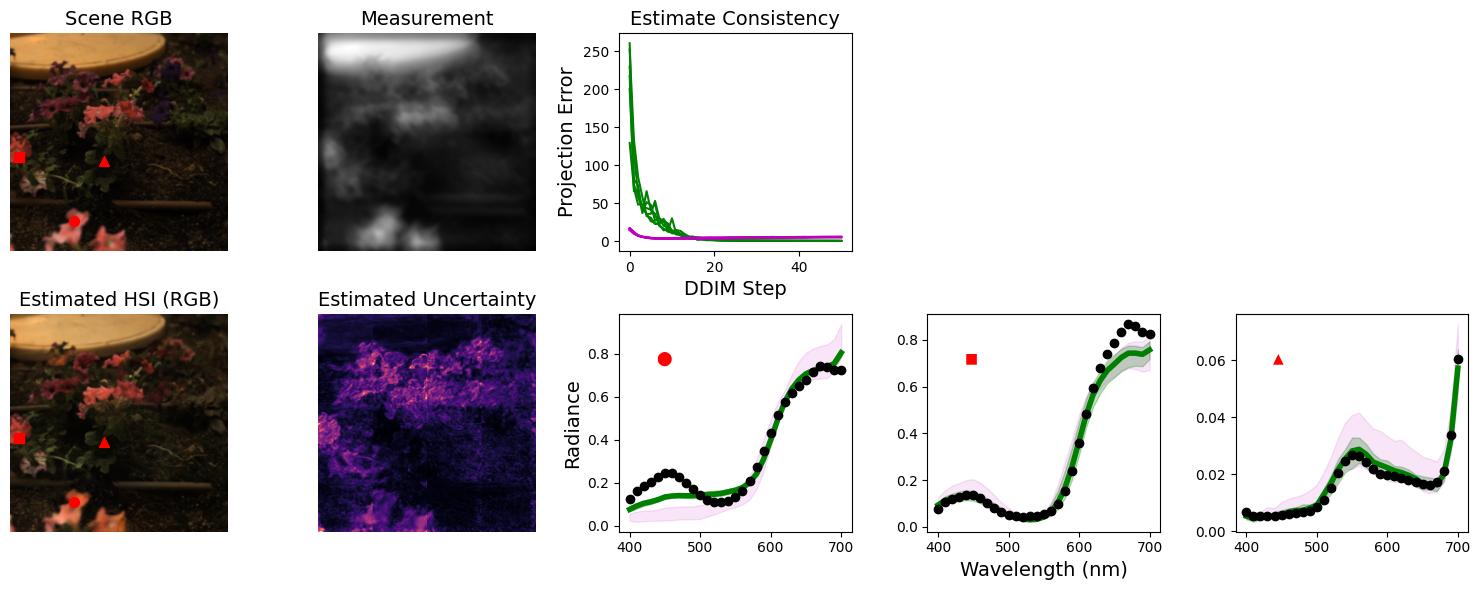

In [13]:
use_loops = 5
use_variance = 6
sampler = DiffSSI(model, n_steps=50, gloop=use_loops, kernel=kernel, mode="gs", gscale=10)

sample = dataset[39]
hsi = sample["hsi"]
mgs = sample["mgs"]
im, x0, loss = sampler.sample(mgs, variance_n=use_variance, use_guidance=True, return_intermediate=False)
ref_im, ref_x0, ref_loss = sampler.sample(mgs, variance_n=use_variance, use_guidance=False, return_intermediate=False)
display_result(hsi, im, ref_im, locs=[(220, 75), [145, 10], [150, 110]])